Limpieza de datos con Python:

* Detección y eliminación de valores duplicados: Asegúrate de que cada registro en el dataset sea único.
* Verificación y ajuste de tipos de datos: Asegúrate de que todas las columnas coincidan con los tipos de datos indicados en el diccionario de datos.
* Consistencia en valores categóricos: Identifica y corrige cualquier inconsistencia en los valores categóricos (por ejemplo, ‘Action’, ‘action’, ‘ACTION’).

Manejo de valores faltantes:
* Identifica y maneja cualquier valor faltante en el dataset. Rellena los valores faltantes con un marcador adecuado para el tipo de dato.
* Detección de datos anómalos: Identifica y corrige cualquier punto de dato inapropiado o inusual (por ejemplo, un videojuego con ventas negativas).

Exploración de datos con Python:
* Visualizaciones exploratorias univariadas: Crea dos tipos diferentes de visualizaciones univariadas. Cada visualización debe incluir una breve interpretación dentro del archivo de código.
* Visualizaciones exploratorias multivariadas: Crea dos tipos diferentes de visualizaciones multivariadas. Cada visualización debe incluir una breve interpretación dentro del archivo de código.

Análisis adicional:
* Estadísticas descriptivas: Proporciona un resumen estadístico del dataset, incluyendo medidas de tendencia central y dispersión para las variables numéricas.
* Identificación de tendencias: Analiza y discute cualquier tendencia notable que observes en los datos, apoyándote en las visualizaciones y estadísticas descriptivas.
* Análisis de correlación: Identifica y analiza las correlaciones más fuertes entre las variables del dataset.
* Predicción de ventas: Utiliza un modelo de regresión simple para predecir las ventas futuras basadas en los datos disponibles.


In [2]:
import pandas as pd
import matplotlib.pyplot as pls
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("vgchartz-2024.csv")

In [3]:
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


In [4]:
df.describe()

,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales
count,4682.000000,18922.000000,12637.000000,6726.000000,12824.000000,15128.000000
mean,7.148676,0.349113,0.264740,0.102281,0.149472,0.043041
std,1.453512,0.807462,0.494787,0.168811,0.392653,0.126643
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.300000,0.030000,0.050000,0.020000,0.010000,0.000000
50%,7.400000,0.120000,0.120000,0.040000,0.040000,0.010000
75%,8.200000,0.340000,0.280000,0.120000,0.140000,0.030000
max,10.000000,20.320000,9.760000,2.130000,9.850000,3.120000


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.dtypes

,0
img,object
title,object
console,object
genre,object
publisher,object
developer,object
critic_score,float64
total_sales,float64
na_sales,float64
jp_sales,float64


In [7]:
df.isnull().sum()

,0
img,0
title,0
console,0
genre,1
publisher,1
developer,8
critic_score,26398
total_sales,12158
na_sales,18443
jp_sales,24354


In [8]:
# Para evaluar la mejor forma de reemplazar los valores nulos, inicialmente se calcula la media y desviación estándar de las columnas con muchos datos nulos
print(df.mean(numeric_only=True))

critic_score    7.148676
total_sales     0.349113
na_sales        0.264740
jp_sales        0.102281
pal_sales       0.149472
other_sales     0.043041
dtype: float64


In [9]:
print(df.std(numeric_only=True))

critic_score    1.453512
total_sales     0.807462
na_sales        0.494787
jp_sales        0.168811
pal_sales       0.392653
other_sales     0.126643
dtype: float64


In [10]:
# Al calcular la desviación, queda en evidencia que los valores cambian demasiado respecto a la media, por lo que no sería recomendable reemplaza por este valor, ya que sería poco representativo
print(abs((((df.mean(numeric_only=True))-(df.std(numeric_only=True)))/(df.mean(numeric_only=True)))*100))

critic_score     79.667394
total_sales     131.289856
na_sales         86.895257
jp_sales         65.047144
pal_sales       162.692950
other_sales     194.241125
dtype: float64


In [11]:
# Finalmente, se decide eliminar los valores nulos de las ventas y en el caso del score de cada juego, los que no tengan valores reemplazarlos por un
df_limpio = df.dropna(subset=["total_sales", "na_sales", "jp_sales", "pal_sales", "other_sales"])

df_limpio.isnull().sum()

# Al revisar el dataset, podemos notar que se borraron los datos nulos de ventas, quedando ahora los correspondientes a calificacion y ultimas actualización

,0
img,0
title,0
console,0
genre,0
publisher,0
developer,0
critic_score,1012
total_sales,0
na_sales,0
jp_sales,0


In [12]:
# Luego, se reemplaza los que no tienen puntaje por 0 y los que no tienen fecha de actualización por "desconocido", siendo este último un criterio no tan relevante
df_limpio["critic_score"] = df_limpio["critic_score"].fillna(0)
df_limpio["last_update"] = df_limpio["last_update"].fillna("Desconocida")
df_limpio["release_date"] = df_limpio["release_date"].fillna("Desconocida")

df_limpio.isnull().sum()


/tmp/ipykernel_9222/3503870822.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio["critic_score"] = df_limpio["critic_score"].fillna(0)
/tmp/ipykernel_9222/3503870822.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio["last_update"] = df_limpio["last_update"].fillna("Desconocida")
/tmp/ipykernel_9222/3503870822.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

,0
img,0
title,0
console,0
genre,0
publisher,0
developer,0
critic_score,0
total_sales,0
na_sales,0
jp_sales,0


In [13]:
# se revisan los valores únicos en las variables categóricas, en este caso todos los nombres listados son únicos
for col in ["developer", "genre", "console", "publisher"]:
    print(f"\n{col}: {df_limpio[col].unique()}")


developer: ['Rockstar North' 'Treyarch' 'Infinity Ward' 'Rockstar Games'
 'Sledgehammer Games' 'DMA Design' 'EA Vancouver' 'EA Canada' 'Bungie'
 '343 Industries' 'EA Sports' 'Bethesda Game Studios' 'EA DICE'
 'Rockstar Leeds' 'Dice' 'EA Black Box' 'EA Los Angeles' 'Naughty Dog'
 'Rockstar San Diego' 'Ubisoft Montreal' 'Mojang'
 'Reflections Interactive' 'Namco' 'Office Create' 'Rocksteady Studios'
 'Turn 10 Studios' "Traveller's Tales" 'Square Enix' 'Core Design Ltd.'
 'EA Tiburon' 'Sega' 'Lionhead Studios' 'Capcom' 'Neversoft Entertainment'
 'BudCat Creations' 'Vicarious Visions' 'Stormfront Studios'
 'Turn 10 Studio' 'Blizzard Entertainment' 'Neversoft'
 'Bethesda Softworks' 'Konami Computer Entertainment Tokyo'
 'Massive Entertainment' 'Ubisoft Montpellier' 'High Moon Studios'
 'Mass Media' 'Capcom / Dimps Corporation' 'Konami' 'Team Fusion'
 'Obsidian Entertainment' 'Cat Daddy Games' 'Visual Concepts' 'Ubisoft'
 'SCE San Diego Studio' 'High Impact Games' 'EA Redwood Shores'
 'Zipp

Análisis:
* Se realiza un histograma que permita evaluar la calificación general de los juegos disponibles en la plataforma, esto puede dar una idea inicial del nivel de satisfacción que tiene el usuario con las opciones disponibles, en este caso, se observa que en general la evaluación es mayor a 7, dando cuenta que existe un nivel de satisfacción aceptable con las opciones.

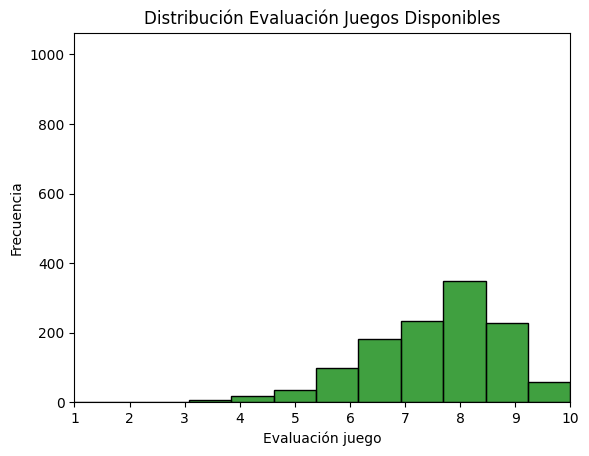

In [14]:
sns.histplot(df_limpio["critic_score"], color="green")
plt.xlabel("Evaluación juego")
plt.ylabel("Frecuencia")
plt.title("Distribución Evaluación Juegos Disponibles")
plt.xlim(1, 10)
plt.show()

Análisis:

* Se realiza una distribución de la frecuencia de juegos por categoría, donde se puede observar una clara predominancia de los juegos de acción, shooter y role playing. El poder identificar que productos son los que dominan, permite dar cuenta del enfoque que están teniendo los desarrolladores en la producción de juegos.

* Además, cabe mencioanr que el contar con una predominancia muy alta de cierto tipo de juegos, puede hacer que la plataforma se acerque más a un nicho de gente y, por lo tanto, afectar su alcance. De igual forma, es necesariio revisar otras variables para tener conclusiones más certeras.

Text(0.5, 1.0, 'Distribución juegos por género en la plataforma')

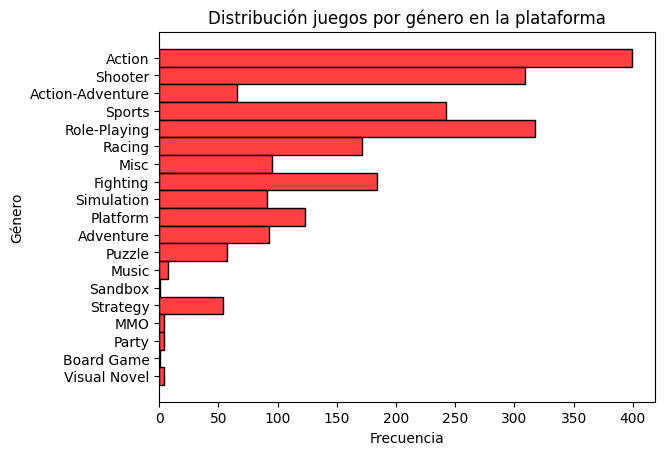

In [15]:
sns.histplot(data=df_limpio, y="genre", color="red")
plt.xlabel("Frecuencia")
plt.ylabel("Género")
plt.title("Distribución juegos por género en la plataforma")

Text(0, 0.5, 'Género juego')

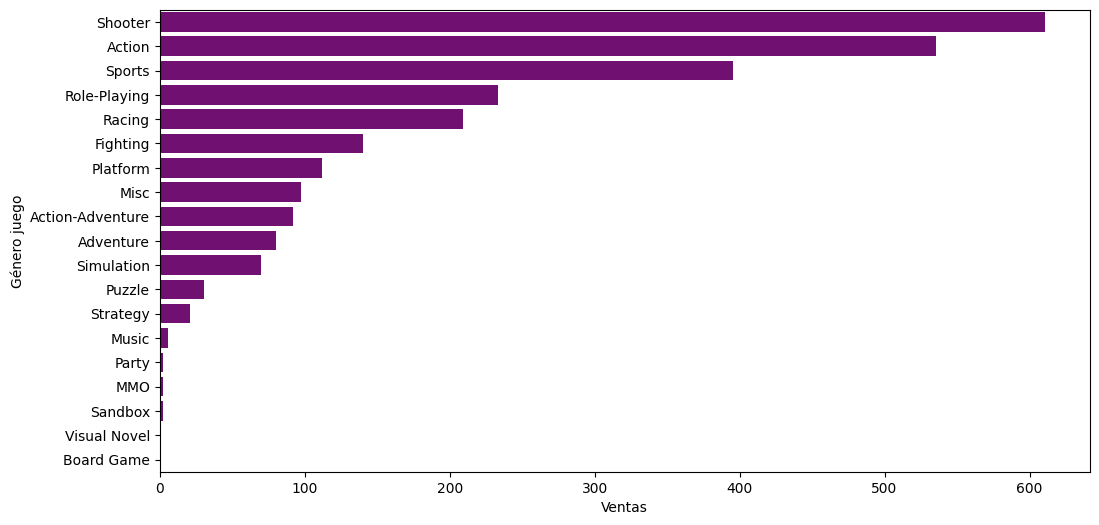

In [17]:
plt.figure(figsize=(12, 6))
sns.barplot(x="total_sales", y="genre", color="purple",
            data=df_limpio.groupby("genre")["total_sales"].sum().reset_index().sort_values("total_sales", ascending=False))
plt.xlabel("Ventas")
plt.ylabel("Género juego")

Análisis

* Se revisa la relación entre ventas y calificación, como es esperable, los juegos que poseen una mayor calificación tienen tambien el nivel de ventas más alto, pudiendo observar una relación prácticamente linea entre las variables clasificación y ventas.
Adempas, se identidican las principales categorías con el color, quedando en evidencia que los juegos más vendidos y con mejor clasificación son los de acción, junto a los shooter y deporte.
Si bien este gráfico permite tener una idea inicial del panorama, es necesario indagar con análisis complementarios para obtener información más concreta.

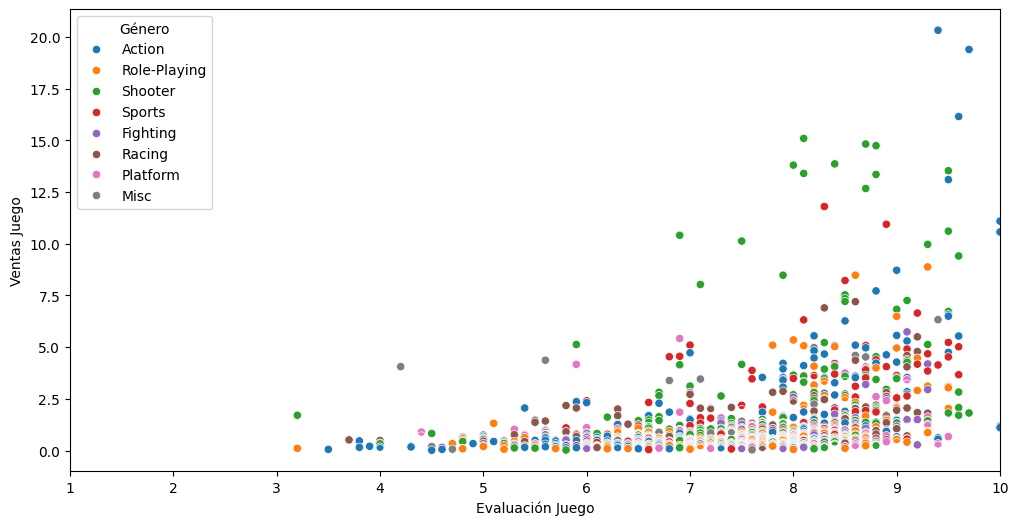

In [18]:
# se identifican los juegos más vendidos ys e limitan a los que tienen mas de 100 millones de ventas
# se grafica la calificación del juego vs la venta y se distinguen por categoría considerando las primeras.
top_generos = df_limpio["genre"].value_counts().nlargest(8).index

plt.figure(figsize=(12, 6))
plt.xlim(1, 10)
sns.scatterplot(x='critic_score', y='total_sales',
                hue='genre', hue_order=top_generos, data=df_limpio)
plt.xlabel("Evaluación Juego")
plt.ylabel("Ventas Juego")
plt.legend(title="Género")
plt.show()

Análisis:

* Se realiza un diagrama de torta para determinar cual es la zona que predomina en ventas, si bien estos gráficos pueden resultar básicos, permiten observar de manera muy eficaz la información.
En este caso, se ve una ampliaprodominancia de Norteamética como principal comprador, seguido de Europa y japón que tienen un valor similar a la acumulación de otras zonas. Por lo tanto, los esfuerzos de la empresa en el corto plazo podrían enfocarse a consolidar aún más norteamérica como principal comprado, identificando que tipo de juegos son los que más consumen.

Text(0.5, 1.0, 'Ventas por zona')

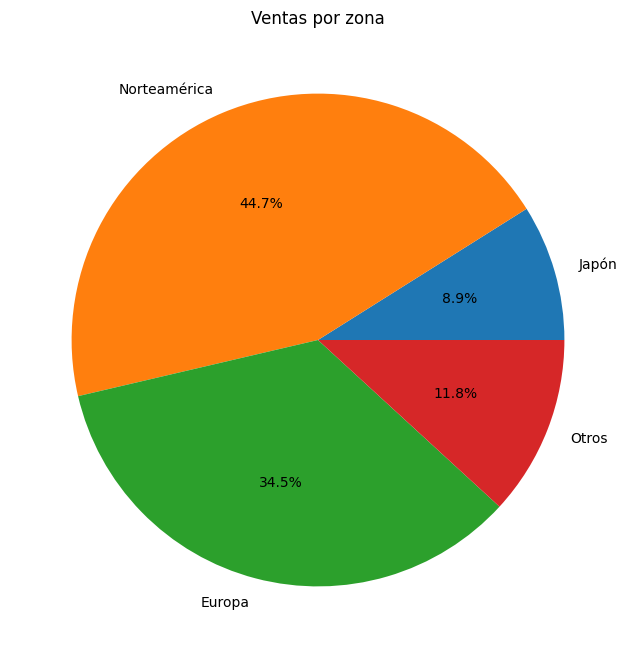

In [22]:
zonas = ["Japón", "Norteamérica", "Europa", "Otros"]
ventas = [df_limpio["jp_sales"].sum(),
          df_limpio["na_sales"].sum(),
          df_limpio["pal_sales"].sum(),
          df_limpio["other_sales"].sum()]

plt.figure(figsize=(8, 8))
plt.pie(ventas, labels=zonas, autopct="%1.1f%%")
plt.title("Ventas por zona")

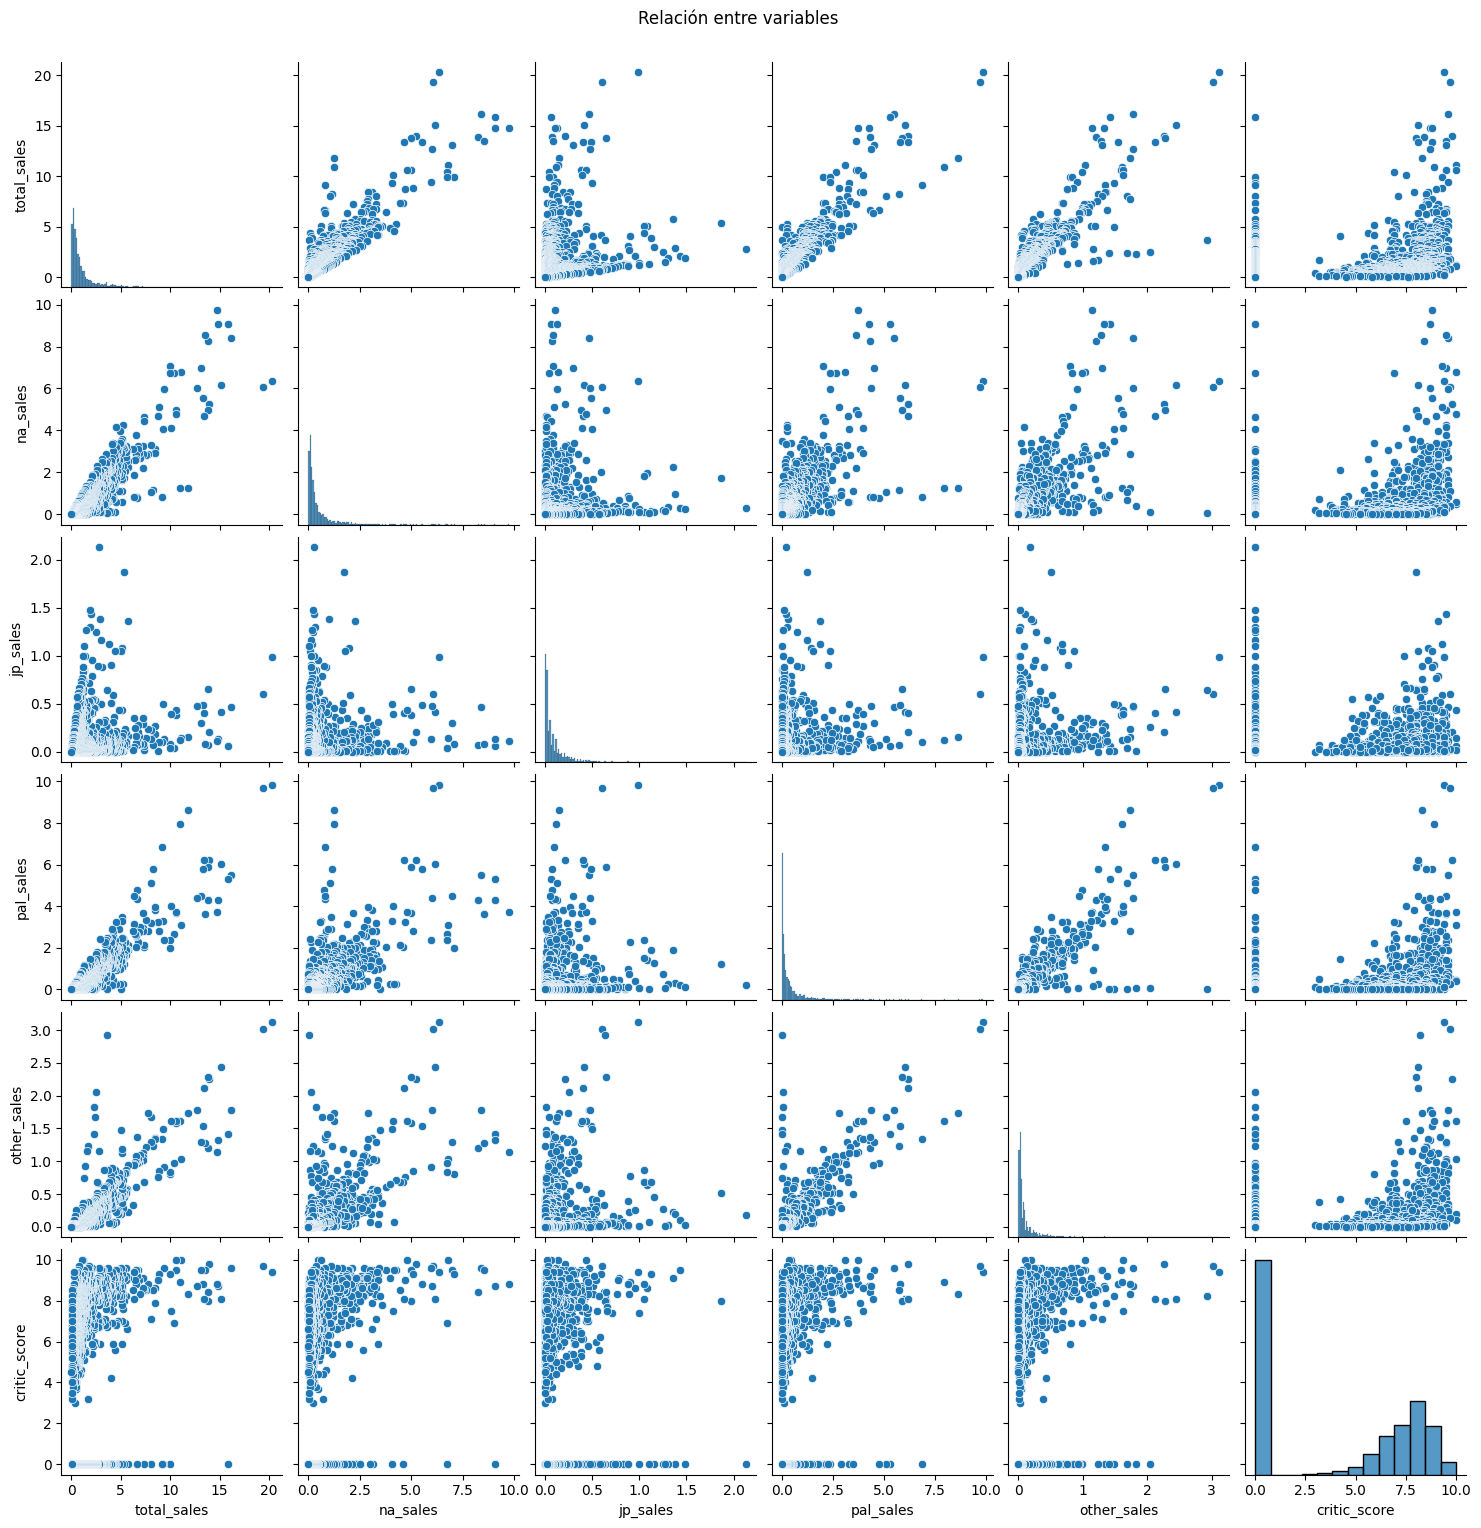

In [23]:
sns.pairplot(df_limpio[["total_sales", "na_sales", "jp_sales", "pal_sales", "other_sales", "critic_score"]])
plt.suptitle("Relación entre variables", y=1.02)
plt.show()